### **A rendre le 11 Mars avant 23h:59mn sur Chamilo dans "Travaux". Utilisation des LLMs est fortement déconseillée**
##### ***N'oubliez pas de preciser vos Nom et Prenom comme nom du ficher notebook***

Support théorique: 
* tp1.pdf partie 1 lissage linéaire depuis https://chamilo.grenoble-inp.fr/courses/ENSIMAG4MMTI6/document/TP/TP1/tp1.pdf?cidReq=ENSIMAG4MMTI6&id_session=0&gidReq=0&gradebook=0&origin=

* Cours2-TI-filtrage-2019.pdf depuis https://chamilo.grenoble-inp.fr/main/document/document.php?cidReq=ENSIMAG4MMTI6&id_session=0&gidReq=0&gradebook=0&origin=&id=1760145

***NB1: Des références et tutoriels en ligne sont donnés à la fin du notebook, vous pouvez aussi les consulter (même avant de commencer le TP).***

***NB2: Essayez de commenter les codes le plus possible et aussi (recommendé) de commenter les erreurs rencontrées et qui vous ont fait galérer le plus. Precisier comment vous avez compris ces erreurs et comment vous avez fait pour les corriger. Cette partie sera plus considérée dans la correction que la solution bien faite.***




# Introduction
Un système d’enregistrement d’image ne restitue pas l’image de manière parfaite : des informations
parasites apparaissent et viennent s’ajouter de manière aléatoire aux éléments de la scène d’origine.
Cet effet est désigné sous le terme général de ”bruit”. La chaine d’acquisition classique comporte donc le phénomène physique (faisceau lumineux, les rayons X au autres), le capteur transformant le phénomène physique en signal électrique, l’amplification du signal et la conversion analogique/numérique.

Les principales sources de bruit sont les suivantes :
*   le bruit lié au phénomène physique mesuré
*   le bruit lié au capteur
*   le bruit lié à l’électronique d’acquisition
*   le bruit lié à la quantification


### Question 1: Quels sont les objectifs du lissage?

Réponse: L'objectif du lissage est de palier au bruit en essayant de se rapprocher de l'image initiale. Cela permet d'obtenir une image plus agréable à regarder et d'améliorer les possibilités de traitement par la suite

# Lissage Linéaire

Cette catégorie de filtres correspond à des filtres passe-bas, éliminant les hautes fréquences qui représentent généralement le bruit. Le problème est de déterminer la fréquence de coupure exacte du filtre car les contours des objets sont eux aussi représentés par des fréquences relativement élevées, qu’il faut conserver.
Le rôle d’un filtre de lissage peut être résumé en quatre actions :
* Tous les pixels d’une zone relativement homogène doivent être à une même valeur : cela revient àréduire la variance de cette zone homogène.
* Tous les pixels proches d’un contour doivent appartenir à une zone homogène s’ils n’appartiennent pas à ce contour. Cela revient à ne pas créer de nouvelles zones ou valeurs à proximité des points de contours.
* Aucun point de contour ne doit disparaître : le filtre ne doit pas entraîner de perte de résolution sur l’image, en particulier sur les zones où les contours ont 1 ou 2 pixels d’épaisseurs (Images de caractères ou d’empreintes digitales par exemple).
* Le filtre ne doit pas entraîner de déformations de ces contours (en particulier pour les coins et les intersections de contours) et ne doit pas déplacer ces contours (en particulier lorsque des mesures métriques sont envisagées).



### Question 2: Quel est l'inconvénient principal du filtre linéaire?

Réponse: Pour essayer de réduire le bruit, le lissage linéaire a pour but de diminuer l'influence des hautes fréquences, qui correspondent souvent au bruit. L'inconvénient principal est que les hautes fréquences correspondent aussi aux contours des objets. Il est donc difficile d'avoir un effet efficace sur le bruit sans perdre d'informations sur les contours. Il faut ajuster l'action du lissage et la fréquence de coupure pour avoir le meilleur résultat, cela va probablement impliquer d'effectuer des compromis.

## **1. FFT, Filtrage Gaussien par FFT:**

### Question 3: Quel est l'intéret de la transformée de Fourier pour le filtrage?

Réponse: Appliquer un filtre à une image consiste à réaliser un produit de convolution entre l'image et le filtre. Or, la transformée de fourier d'un produit de convolution, est le produit des transformées de fourier des deux facteurs. Pour appliquer un filtre, on peut donc multiplier les transformées de Fourier du filtre et de l'image, puis réaliser une transformée inverse. Cela permet un calcul beaucoup plus rapide car souvent on connaît la TF du filtre, et les calculs de TF sont plus rapides que la convolutin grâce aux algorithmes de FFT. 

### Question 4: Citer 3 propriétés du produit de convolution.

Réponse: Le produit de convolution est bilinéaire, associatif, et commutatif.

### Question 5 : Implémentez dans le domaine discret la transformée de Fourier de la gaussienne 2D, exprimée par $\text{TF}(G(u, v))$ ci-dessous. Visualisez l'amplitude du résultat en échelle logarithmique.

$$\text{TF}(G(u, v)) = \exp\left( -2\pi^2 \sigma^2 \left( \left(\frac{u - N/2}{N}\right)^2 + \left(\frac{v - M/2}{M}\right)^2 \right) \right)$$
$$\quad \text{avec} \quad 0 \leq u < N \quad \text{et} \quad 0 \leq v < M$$

### **Remarque 1:** attention, ici $\text{TF}(G(u, v))$ est centrée sur le milieu de l’image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io

/opt/python-ensimag/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def gaussian_2d_fourier(N, M, sigma):

    #au début je pensais utiliser np.zeros((N,M)), puis faire une double boucle for
    #mais au final il est baeucoup plus efficace de faire deux matrices avec np.meshgrid
    #puis de calculer le terme sur u, puis sur v, puis de mettre les deux au carré, puis additioner et lever à l'exp

    # Créer une grille de taille N, M, vous pourrez utiliser np.meshgrid
    v,u = np.meshgrid(np.arange(0, M), np.arange(0,N))                  
    
    # Appliquer la formule
    tf_gaussian = np.exp(-2*(np.pi)**2*sigma**2*( ((u-N/2)/N)**2 + ((v-M/2)/M)**2 ))

    return tf_gaussian 

/tmp/ipykernel_51030/2089571828.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(tf_gaussian), cmap='hot', extent=[0, N, 0, M])


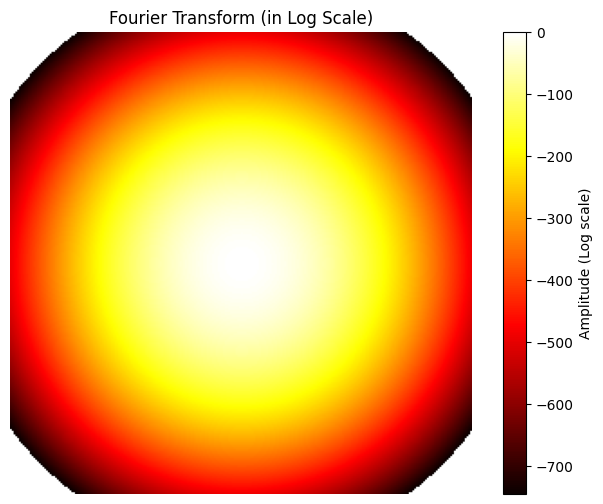

In [3]:
N, M = 256, 256 
sigma = 10

# Calcul de la transformée de Fourier de la gaussienne
tf_gaussian = gaussian_2d_fourier(N,M,sigma)
# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(np.log(tf_gaussian), cmap='hot', extent=[0, N, 0, M])
plt.title('Fourier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

### Question 6: 
* ### Visualisez l'image mandrill256.pgm. 
* ### Calculer sa transformée de Fourier en utilisant la fonction numpy np.fft.fft2(image) puis visualiser le résultat.
* ### Visualisez np.fft.fftshift(np.fft.fft2(image)). Que fait np.fft.fftshift ? Quelle propriété de la transformée de Fourier est utilisée ? Pourquoi fait-on cela ?

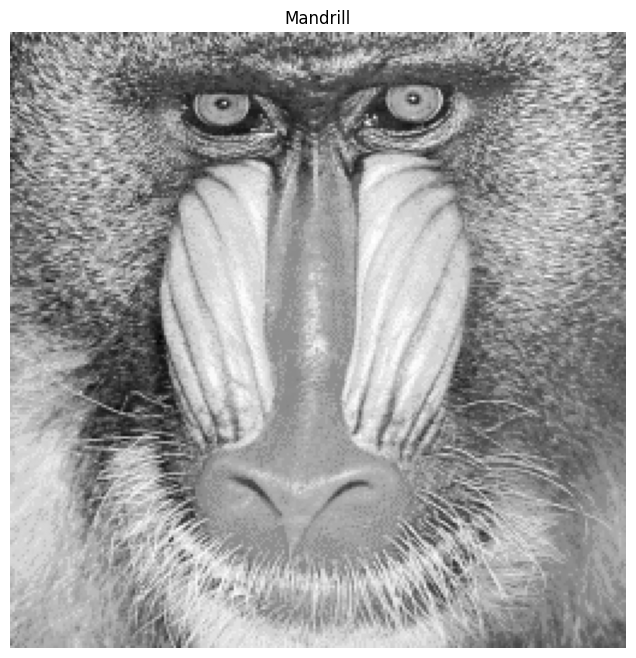

In [4]:
#je ne comprenais pas comment l'ouvrir
#j'ai vu l'import skimage
#après quelques recherches j'ai trouvé skimage.imread(fichier)
mandrill = io.imread("mandrill256.pgm")
plt.figure(figsize=(8, 8))
plt.imshow(mandrill, cmap = 'gray')
plt.title('Mandrill')
plt.axis('off') 
plt.show()

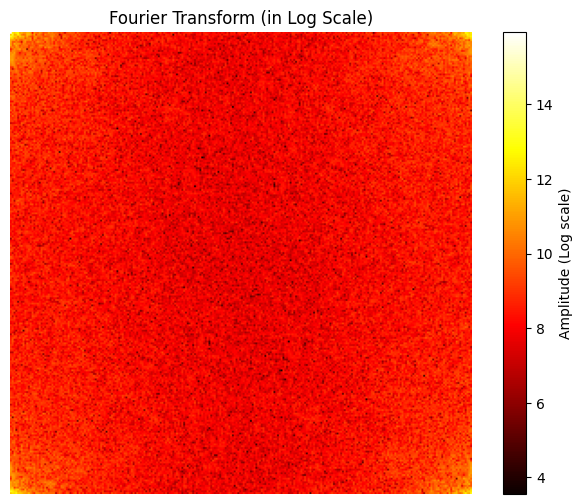

In [5]:
# Calcul de la transformée de Fourier
#au début j'ai fait juste np.fft.fft2(mandrill) mais j'avais une erreur car c'est des complexes
#il faut donc prendre le module, puis l'echelle log
tf_mandrill = np.log(np.abs(np.fft.fft2(mandrill)))

# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(tf_mandrill, cmap='hot')
plt.title('Fourier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

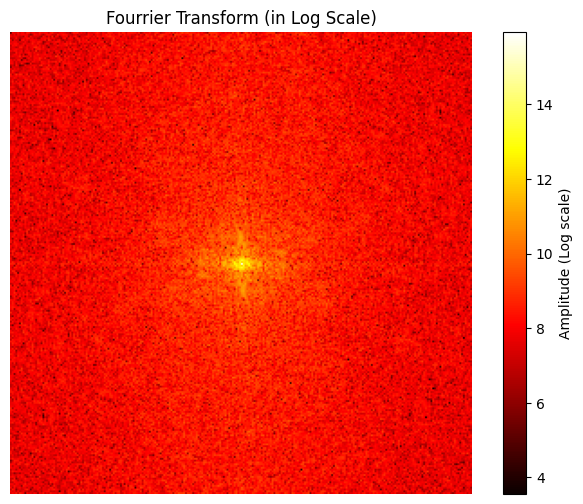

In [6]:
# Calcul de la transformée de Fourier

tf_mandrill_shifted = np.fft.fftshift(tf_mandrill)

# Visualisation en échelle logarithmique
plt.figure(figsize=(8, 6))
plt.imshow(tf_mandrill_shifted, cmap='hot')
plt.title('Fourrier Transform (in Log Scale)')
plt.colorbar(label='Amplitude (Log scale)')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

On remarque que la transformée de Fourier shiftée ressemble à la visualisatin usuelle de la transformée de Fourier, alors que la transformée par défaut est décalée de N/2 valeurs. C'est parce que l'algorithme de la FFT calcule la FFt avec des valeurs de O à N, alors que l'on la visualise généralement de -N/2 à N/2. Il suffit d'utiliser la périodicité de la transformée de Fourier pour reconstruire la visualisatin usuelle.

### Question 7: 
* ### Utilisez la transformation de Fourier rapide (FFT) pour appliquer le filtre gaussien dans le domaine fréquentiel.
* ### Visualisez le résultat sur mandrill256.pgm.

In [7]:
def frequency_gaussian_filter(image, sigma):
    
    
    tf_image = np.fft.fftshift(np.fft.fft2(image))
    tf_gaussian = gaussian_2d_fourier(image.shape[0], image.shape[1], sigma)

    #au début j'avais oublié de déshifter l'image avant de faire ifft2, j'ai eu des problèmes
    filtered_image = np.fft.ifft2(np.fft.ifftshift(tf_image*tf_gaussian))
    return np.abs(filtered_image), tf_gaussian

In [8]:
# Load the image using skimage
mandrill = io.imread("mandrill256.pgm")
sigma = 10
filtered_mandrill, gaussian_filter_on_mandrill = frequency_gaussian_filter(mandrill, sigma = sigma)

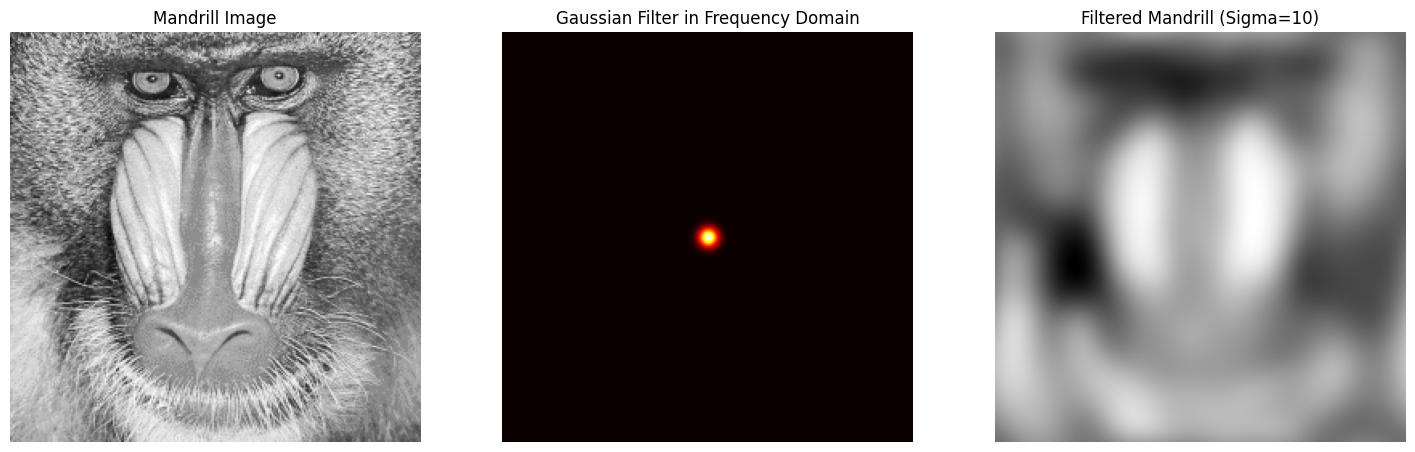

In [9]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gaussian_filter_on_mandrill, cmap='hot')  # Log scale for visibility
plt.title('Gaussian Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma})')
plt.axis('off')

plt.show()


### Question 9: On souhaite corrompre l'image mandrill256.pgm. 
* ### Implémentez une fonction qui rajoute un bruit gaussien (moyenne 0, écart-type std) à une image. 
* ### Testez et visualisez sur mandrill256.pgm (std = 50).

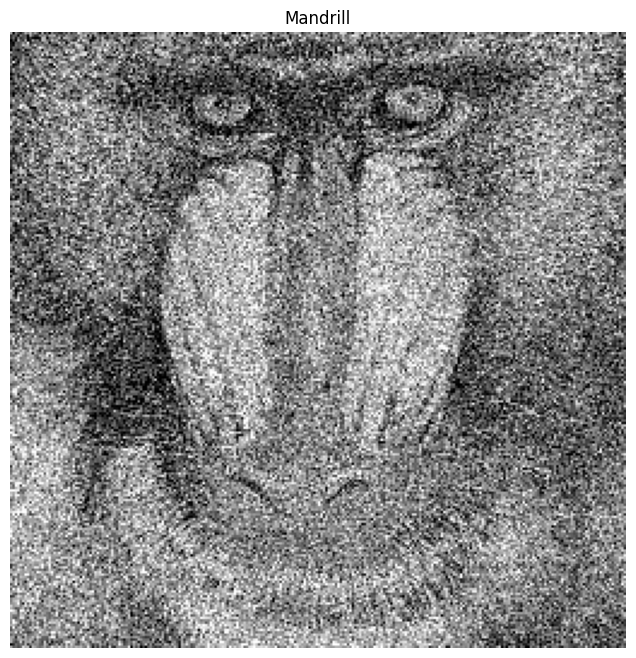

In [10]:
def add_white_noise(image, mean=0, std=10):
        
    noise = np.random.normal(loc = mean, scale = std, size = (image.shape[0], image.shape[1]))
    noisy_image = image + noise
    
    noisy_image = np.clip(noisy_image, 0, 255)
    
    return noisy_image


noisy_mandrill = add_white_noise(mandrill, mean=0, std=50)

plt.figure(figsize=(8, 8))
plt.imshow(noisy_mandrill, cmap='gray')
plt.title('Mandrill')
plt.axis('off') 
plt.show()


### Question 8: Nous souhaitons étudier l'effet du paramètre sigma. Tracez la courbe PSNR entre mandrill256.pgm et le résultat de l'application du filtre gaussien FFT sur sa version corrompue en fonction de plusieurs valeurs de sigma du filtre (par exemple, des valeurs entre 0.1 et 10). Que remarquez-vous ?

* ### Pour rappel si l’image non bruitée est connue, une mesure de comparaison est le Peak Signal Noise Ratio (PSNR) basé sur l’erreur quadratique entre l’image non bruitée connue que l’on cherche et l’image lissée qui approxime cette image. Plus l’image lissée ressemble à l’image recherchée, plus le PSNR est grand. Le PSNR est donné par : 

$$
\text{PSNR}(im_1, im_2) = 10 \log_{10} \left( \frac{(P_{\text{max}})^2}{\text{MSE}} \right)
$$

* ### où l'**erreur quadratique moyenne (MSE)** est définie par :

$$
\text{MSE} = \frac{1}{N \times M} \sum_{i=0}^{N-1} \sum_{j=0}^{M-1} \left(im_1(i, j) - im_2(i, j)\right)^2
$$

* ### où $P_{\text{max}}$ est la valeur maximale d'un pixel, 255 dans notre cas.

In [11]:
def calculate_psnr(im1, im2, pmax=255.0):    

    mse = np.sum((im1-im2)**2)/im1.shape[0]/im1.shape[1]
    
    psnr = 10*np.log10(pmax**2/mse)
    return psnr

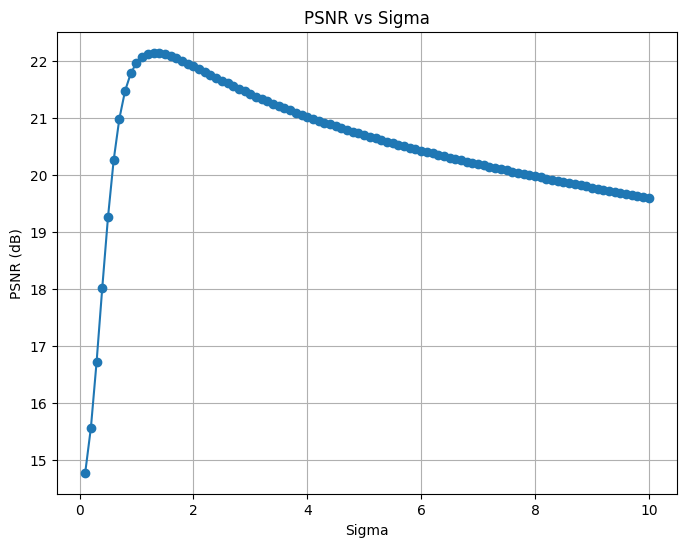

In [13]:
sigmas = np.linspace(0.1,10,100)
psnrs = []

for sigma in sigmas:
    filtered_mandrill ,_ = frequency_gaussian_filter(noisy_mandrill, sigma)
    psnr = calculate_psnr(mandrill, filtered_mandrill)
    psnrs.append(psnr)

plt.figure(figsize=(8, 6))
plt.plot(sigmas, psnrs, marker='o')
plt.title('PSNR vs Sigma')
plt.xlabel('Sigma')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()


Plus le psnr est haut, plus l'image est proche de l'image de base. Ici on remarque sur la première partie de la courbe pour sigma entre 0.1 et 1.5, le psnr augmente. C'est logique, on prend la moyenne de plus de pixels dans notre filtre, donc le bruit ajouté a moins d'impact. Toutefois, lorsque $\sigma > 1.5$, le PSNR diminue lorsque $\sigma$ augmete.

C'est très cohérent et cela rejoint les limites du lissage évoquées en début de TP : lorsque $\sigma$ devient trop grand, les contours de l'image de base deviennent trop flous, et l'image s'éloigne de l'image initiale.

### Question 9: On vous donne dans imagestp/ImagesSynthetiques.zip des images synthétiques construites à partir d’une image parfaite (formes2.pgm), qui subit un filtrage passe bas (formes2g.pgm) à laquelle on ajoute ensuite un bruit de type :
    -  gaussien de moyenne nulle et de variance i pour les images formes2bbi.pgm (1 seule réalisation par variance)
    -  poissonien pour les images formes2pi.pgm (plusieurs réalisations différentes)
    -  poivre et sel pour les images formes2spi.pgm, avec des densité de pixels défectueux différentes
    -  peckle, pour les images formes2si.pgm (bruit multiplicatif dont le coefficient est de distribution gausienne nulle et de variance i)

* ### Appliquez le filtre gaussian sur ces images. Comparer qualitativement (i.e. observations visuelles) les résultats obtenus pour les différents types de bruit (gaussien, poisson, speeckle, poivre et sel).
* ### Pour quel type de bruit le filtre gaussien est-il efficace ?

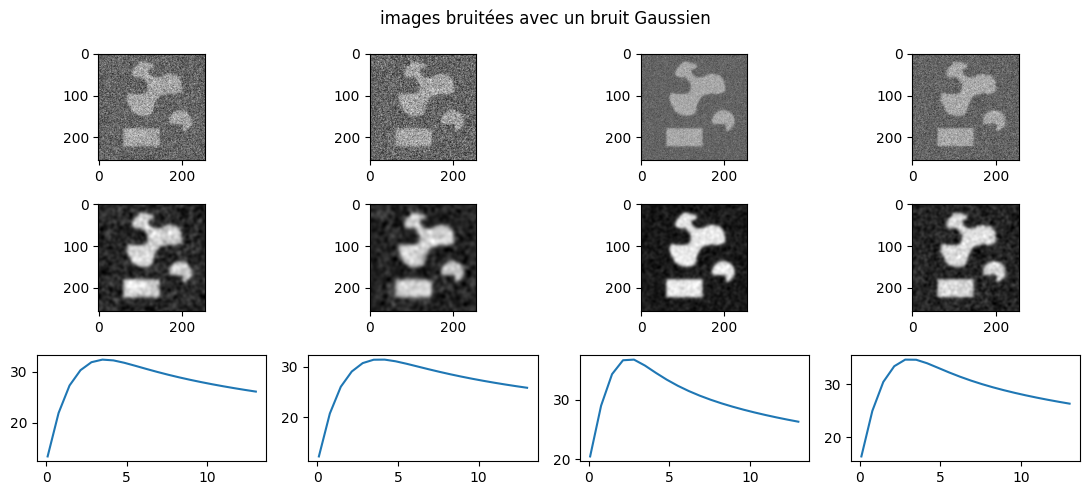

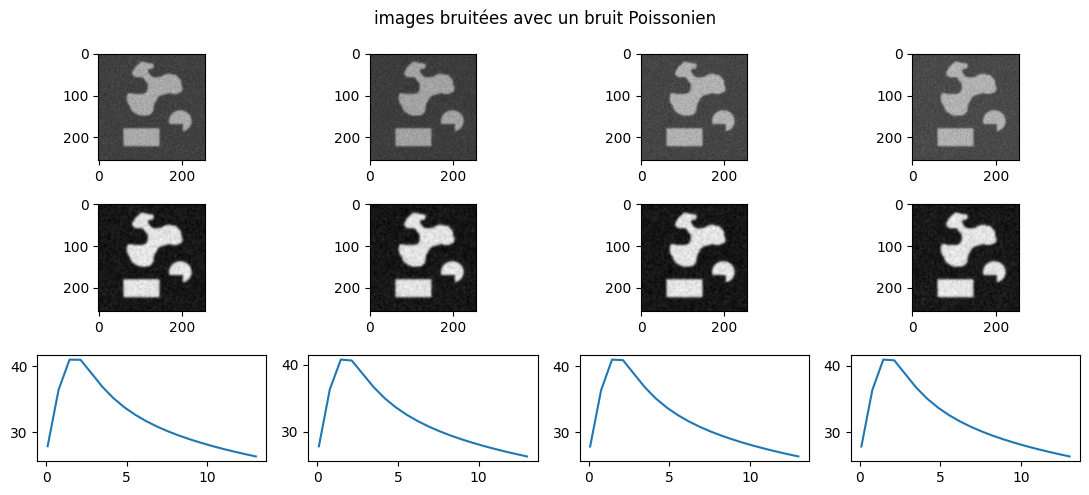

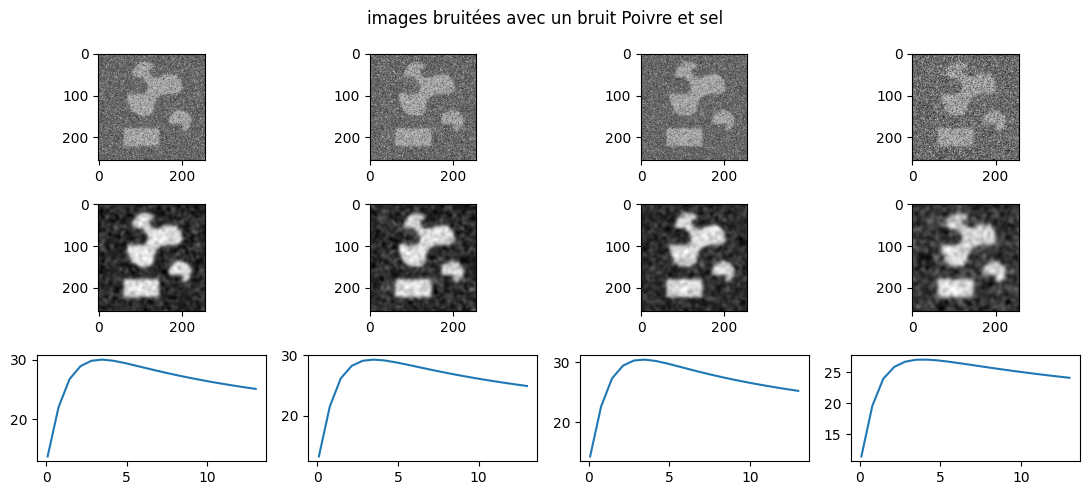

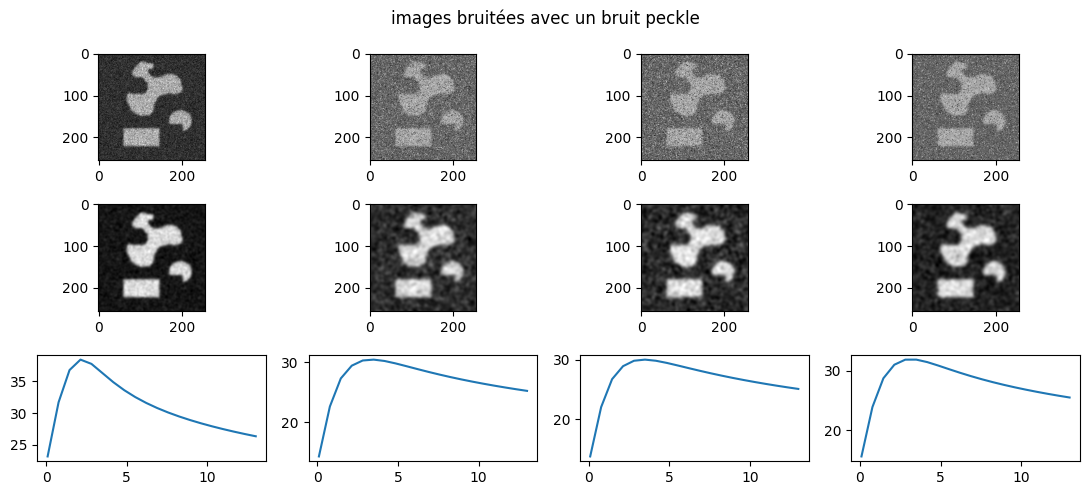

In [14]:
from os import listdir
import random

def select_best_sigma(image, image_initiale):
    sigmas = np.linspace(0.1,13,20)
    psnrs = np.zeros((20,))
    psnr_max = 0
    filtered_image_final = np.zeros_like(image)

    for i,sigma in enumerate(sigmas):
        filtered_image ,_ = frequency_gaussian_filter(image, sigma)
        psnr = calculate_psnr(image_initiale, filtered_image)
        psnrs[i] = psnr
        if psnr > psnr_max:
            psnr_max = psnr
            filtered_image_final = filtered_image
    return filtered_image_final, sigmas, psnrs
    


fichiers = [f for f in listdir('Archive')]
fichiers_par_bruit = {'Gaussien'  : [f for f in fichiers if 'formes2bb' in f], 
                      'Poissonien' : [f for f in fichiers if 'formes2p' in f],
                      'Poivre et sel' : [f for f in fichiers if 'formes2sp' in f],
                      'peckle' : [f for f in fichiers if 'formes2s' in f]}

image_initiale = io.imread('Archive/formes2g.pgm')

for type_bruit in fichiers_par_bruit.keys():
    images = fichiers_par_bruit[type_bruit]
    #on va garder 4 images par bruit pour une meilleure lisibilité
    images_4 = random.sample(images, 4)

    fig,ax = plt.subplots(3, len(images_4), figsize=(11,5))
    fig.suptitle("images bruitées avec un bruit "+type_bruit)
    
    for i,f in enumerate(images_4):
        image = io.imread('Archive/'+f)
        #on va selectionner le meilleur sigma pour l'image
        filtered_image, sigmas, psnrs = select_best_sigma(image, image_initiale)
        ax[0,i].imshow(image, cmap = 'gray')
        ax[1,i].imshow(filtered_image, cmap = 'gray')
        ax[2,i].plot(sigmas,psnrs)
    plt.tight_layout()
    plt.show()

J'ai eu du mal à faire cette question car je ne savais pas quelle valeur prendre pour $\sigma$ pour chaque image. Cela n'a pas de sens de comparer l'efficacité du filtre pour un $\sigma$ identique pour toutes les images étant donné qu'elles sont faites avec des bruits de nature différentes et d'écarts-types différents. Peut-être que le sigma optimal n'est pas le même pour toutes les images. J'ai donc fait une fonction qui selectionne le meilleur $\sigma$ du filtre gaussien pour chaque image, et qui affiche la courbe du $PSNR$ en fonction de $\sigma$, en me basant sur le psnr entre l'image débruitée, et l'image initiale (formes2g.pgm). Je compare donc l'efficacité du meilleur filtre gaussien pour chaque image. 

Pour une meilleure visibilité, j'affiche 4 images par type de bruit. J'affiche l'image initiale, l'image débruitée, et la courbe $PSNR = f(\sigma)$.

A vue d'oeil, il semble que le filtrage gaussien fonctionne très bien pour le bruit poissonien. Pour le bruit peckle et pour le bruit Gaussien c'est aussi plutôt satisfaisant pour des petites valeurs de variance. pour le bruit sel/poivre, l'image débruitée est rapidement altérée dès lors qu'il y avait trop de bruit initial.

Ces observations à vue d'oeil sont rejointes par les scores de similarités $PSNR$ qui sont plus élevés pour le bruit poissonien, et assez bas pour le bruit sel/poivre

### Question 10: Creation d'une image hybride. Nous souhaitons implementer ces filtres dans le domaine spectrale:

* ### Filtre passe bas:
$$H(u, v) =
\begin{cases}
1 & \text{if } \sqrt{(u - N/2)^2 + (v - M/2)^2} \leq r \\
0 & \text{otherwise}
\end{cases}$$

* ### Filtre pass haut:
$$
H(u, v) =
\begin{cases}
0 & \text{if } \sqrt{(u - N/2)^2 + (v - M/2)^2} \leq r \\
1 & \text{otherwise}
\end{cases}
$$


### Question 10.1: Implémentez une fonction filtre passe-bas dans le domaine fréquentiel. Testez et visualisez sur monroe.pgm

In [15]:
def filtre_passe_bas(image, radius):
    N = image.shape[0]
    M = image.shape[1]
    v,u = np.meshgrid(np.arange(0,M),np.arange(0,N))
    distance_matrix = np.sqrt((u-N/2)**2 + (v-M/2)**2)
    filter_LP = distance_matrix <= radius

    tf_image = np.fft.fftshift(np.fft.fft2(image))
    
    filtered_image = np.fft.ifft2(np.fft.fftshift(tf_image*filter_LP))
    return np.abs(filtered_image), filter_LP

j'ai eu des problèmes avec cette question car les dimensions de u et v n'étaient pas bonnes : j'avais (700,500) au lieu de (500,700). le problème venait du np.meshgrid. il fallait inverser N et M. naÏvement dans l'exercice 1 j'avais mis u,v = np.meshgrid(np.arange(0,N),np.arange(0,M)). Sauf que cela renvoie alors deux matrice de taille (M, N). ensuite il faut aussi inverser u et v car u représente les valeurs selon la ligne, et v représente la valeur selon la colonne. J'ai passé du temps à comprendre cela pour arriver à v,u = np.meshgrid(np.arange(0,M),np.arange(0,N))

In [16]:
monroe = io.imread('monroe.pgm')
monroe_filtered, low_pass_filter = filtre_passe_bas(monroe, radius=20)

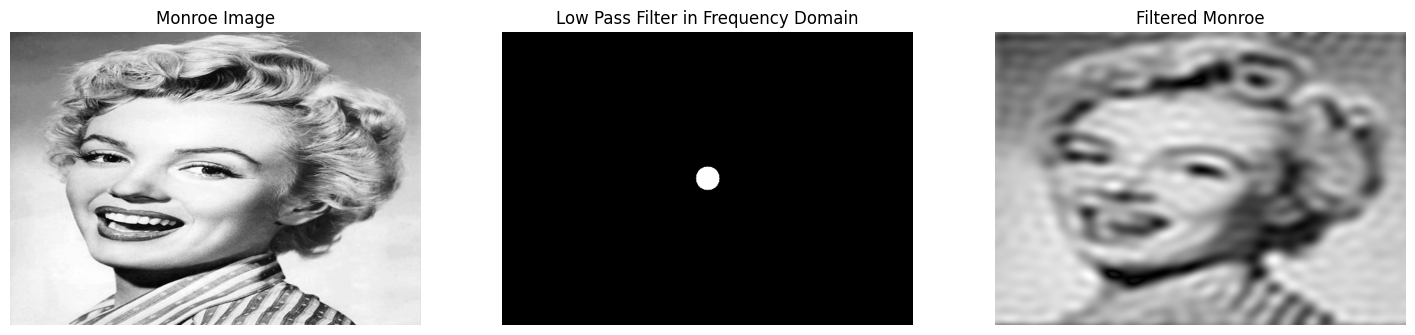

In [17]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(monroe, cmap='gray')
plt.title('Monroe Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(low_pass_filter, cmap='gray')  # Log scale for visibility
plt.title('Low Pass Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(monroe_filtered, cmap='gray')
plt.title(f'Filtered Monroe')
plt.axis('off')

plt.show()

### Question 10.2: Implémentez une fonction filtre passe-haut dans le domaine fréquentiel. Testez et visualisez sur einstein.pgm

In [18]:
def filtre_passe_haut(image, radius):
    N = image.shape[0]
    M = image.shape[1]
    v,u = np.meshgrid(np.arange(0,M),np.arange(0,N))
    distance_matrix = np.sqrt((u-N/2)**2 + (v-M/2)**2)
    filter_LP = distance_matrix > radius

    tf_image = np.fft.fftshift(np.fft.fft2(image))
    
    filtered_image = np.fft.ifft2(np.fft.fftshift(tf_image*filter_LP))
    return np.abs(filtered_image), filter_LP

In [19]:
einstein = io.imread('einstein.pgm')
einstein_filtered, high_pass_filter = filtre_passe_haut(einstein, radius=3)

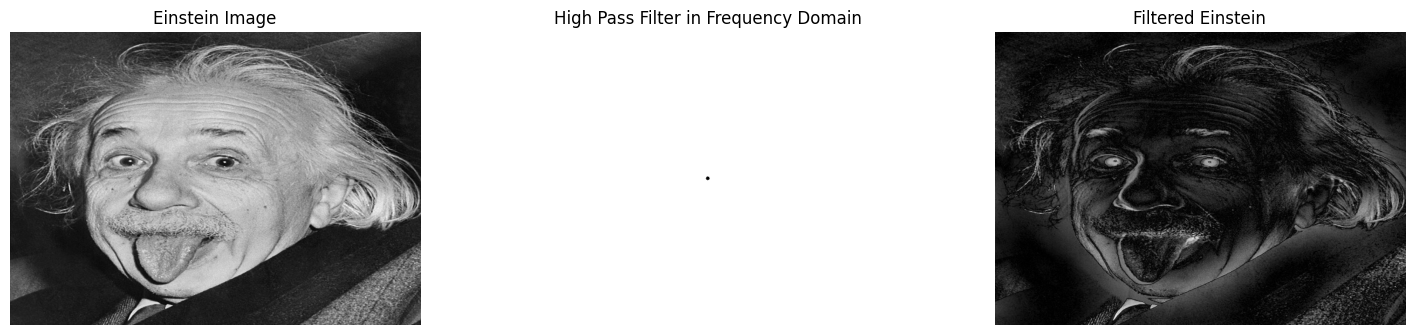

In [20]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(einstein, cmap='gray')
plt.title('Einstein Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(high_pass_filter, cmap='gray')  # Log scale for visibility
plt.title('High Pass Filter in Frequency Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(einstein_filtered, cmap='gray')
plt.title(f'Filtered Einstein')
plt.axis('off')

plt.show()

### Question 10.3: Moyennez les deux images filtrées. Regardez de loin, puis de près, et concluez.

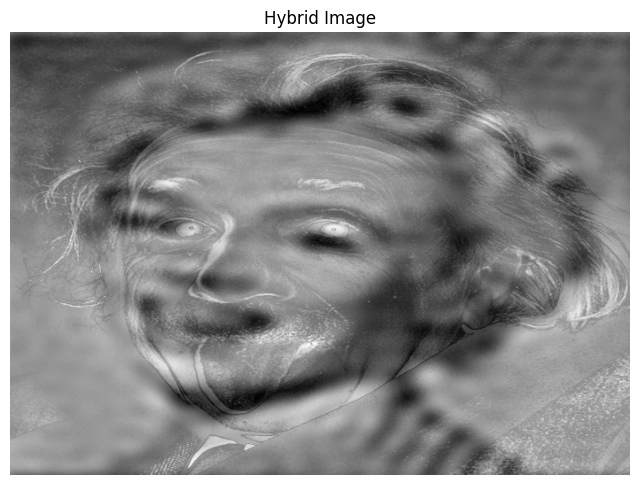

In [21]:
hybrid_image = (einstein_filtered + monroe_filtered) /2
plt.figure(figsize=(8, 8))
plt.imshow(hybrid_image, cmap='gray')
plt.title('Hybrid Image')
plt.axis('off') 
plt.show()

De loin on voit Marylin Monroe, et de près on voit Enstein. C'est sûrement que le pouvoir de résolution de l'oeil ne permet pas de distinguer les hautes fréquences de loin, qui forment des contours très fin. Marylin Monroe apparaît donc. Par contre de près on voit bien Einstein apparaître, alors que Marylin Monroe disparait et devient une simple couleur de fond.

## **2. Convolution Spatiale:**


### Dans le domaine discret, une convolution entre une image $I$ et un filtre $G$ est définie par :

$$R(x, y) = \sum_{i=-n}^{n} \sum_{j=-m}^{m} I(x + i, y + j) \cdot G(i, j)$$


### **Remarque 2, problèmes des bords :** dans le domaine numérique, l'image est de taille finie. La convolution des pixels aux bords de l'image fait appel à des pixels situés en dehors de l'image. Ces pixels peuvent prendre les valeurs suivantes :
* ### Zéro.
* ### La valeur du pixels du bord : on prolonge l’image par continuité.
* ### La valeur des pixels du bord opposé de l’image : on périodise l’image. C’est cette version qui sera utilisée ici pour permettre une comparaison avec le lissage par FFT qui périodise l’image par définition. Vous pourrez utiliser numpy.pad avec le mode='wrap'.

### Question 11: Implémentez un filtre de convolution gaussien de taille n (n=m), et d'écart type sigma. Visualisez pour un choix de n et de sigma.

In [22]:
def gaussian_kernel(n, sigma):

    terms = np.exp(-np.arange(-n,n+1)**2/(2*sigma**2))
    j,i = np.meshgrid(terms, terms)
    kernel = i*j
    
    return kernel / np.sum(kernel)

In [23]:
sigma = 3
n = 5
kernel = gaussian_kernel(n, sigma)
print(kernel.shape)

(11, 11)


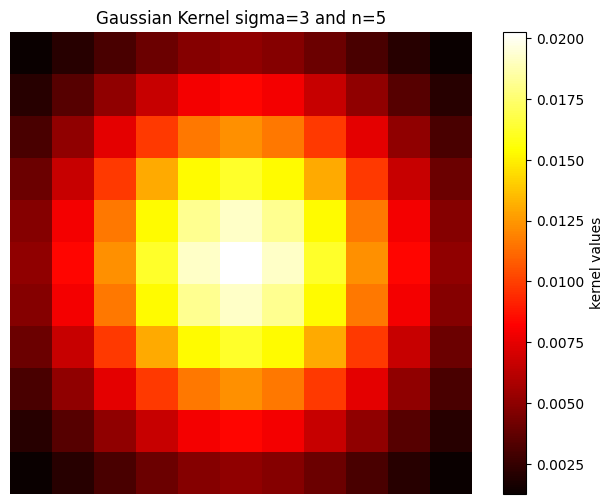

In [24]:
plt.figure(figsize=(8, 6))
plt.imshow(kernel, cmap='hot')
plt.title(f'Gaussian Kernel sigma={sigma} and n={n}')
plt.colorbar(label='kernel values')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

### Question 12: Appliquez ce filtre de convolution sur mandrill256.pgm et visualisez le résultat.

In [25]:
def apply_filter(image, kernel):

    n = int((kernel.shape[0]-1)/2)

    pad_image = np.pad(image, n, mode='wrap')
    filtered_image = np.zeros(image.shape)
    
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            filtered_image[x,y] = np.sum(pad_image[x:x+2*n+1,y:y+2*n+1]*kernel)

    filtered_image = np.clip(filtered_image, 0, 255)

    return filtered_image

In [26]:
filtered_mandrill_spatial_2d = apply_filter(mandrill, kernel)

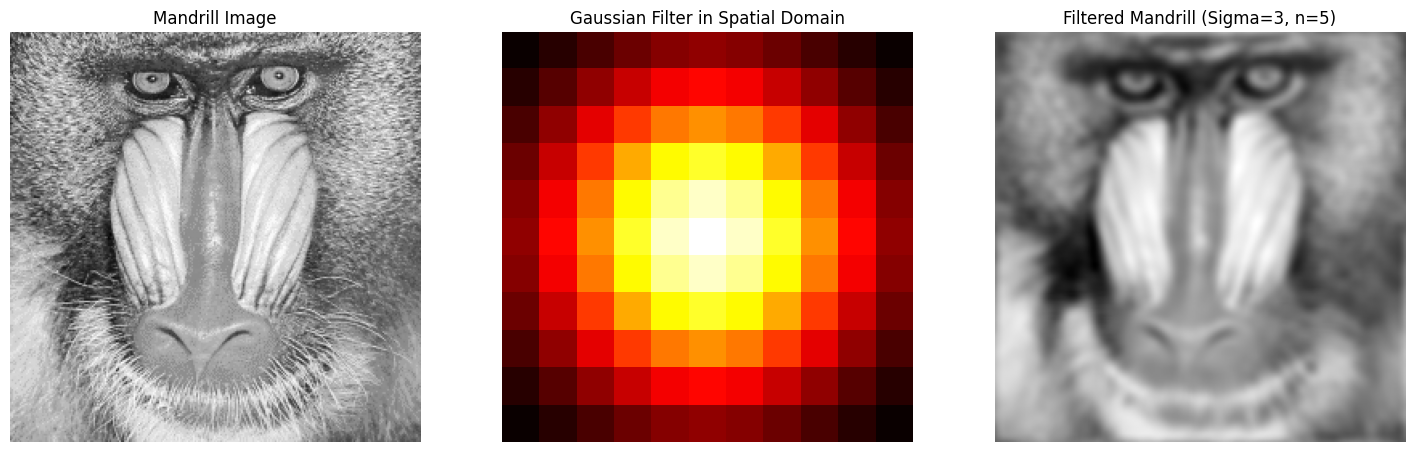

In [34]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(kernel, cmap='hot')  # Log scale for visibility
plt.title('Gaussian Filter in Spatial Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill_spatial_2d, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma}, n={n})')
plt.axis('off')

plt.show()

### Question 14: Le filtre gaussien dans le domaine spatial est une fonction qui suit une loi gaussienne bidimensionnelle, laquelle peut être factorisée en un produit de deux fonctions gaussiennes unidimensionnelles. Cela permet de séparer la convolution 2D en deux convolutions 1D successives. 

* ### Implémentez et visualisez un filtre gaussien 1D. Implémentez un filtre spatial gaussien en utilisant deux convolutions 1D successives. Visualisez le résultat sur mandrill256.pgm. 
* ### Quel est l'avantage d'utiliser deux filtres 1D successifs plutôt qu'un filtre 2D ?

In [35]:
def gaussian_kernel_1d(n, sigma):
    kernel = np.exp(-np.arange(-n,n+1)**2/(2*sigma**2))
    kernel /= np.sum(kernel) 
    return kernel

In [36]:
sigma = 3
n = 5
kernel_1d = gaussian_kernel_1d(n,sigma)
print(kernel_1d.shape)

(11,)


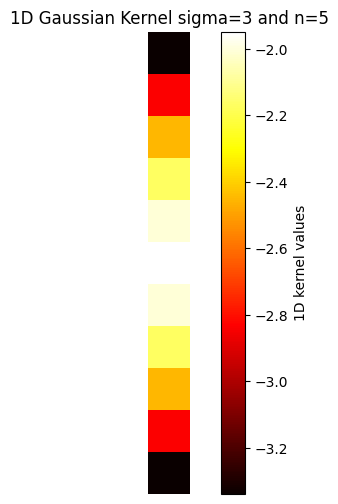

In [37]:
plt.figure(figsize=(8, 6))
plt.imshow(np.log(kernel_1d.reshape(2*n+1,1)), cmap='hot')
plt.title(f'1D Gaussian Kernel sigma={sigma} and n={n}')
plt.colorbar(label='1D kernel values')
plt.xlabel('u')
plt.ylabel('v')
plt.axis('off')
plt.show()

In [49]:
def apply_1d_row_cols(image, kernel):

    n = int((kernel.shape[0]-1)/2)

    pad_image = np.pad(image, n, mode='wrap')
    filtered_image = np.zeros(image.shape)
    G1 = np.copy(pad_image)

    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            G1[x+n,y+n] = np.sum(pad_image[x:x+2*n+1,y+n]*kernel)

    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            filtered_image[x,y] = np.sum(G1[x+n,y:y+2*n+1]*kernel)

    filtered_image = np.clip(filtered_image, 0, 255)
    
    return filtered_image

In [50]:
filtered_mandrill_spatial_1d = apply_1d_row_cols(mandrill, kernel_1d)

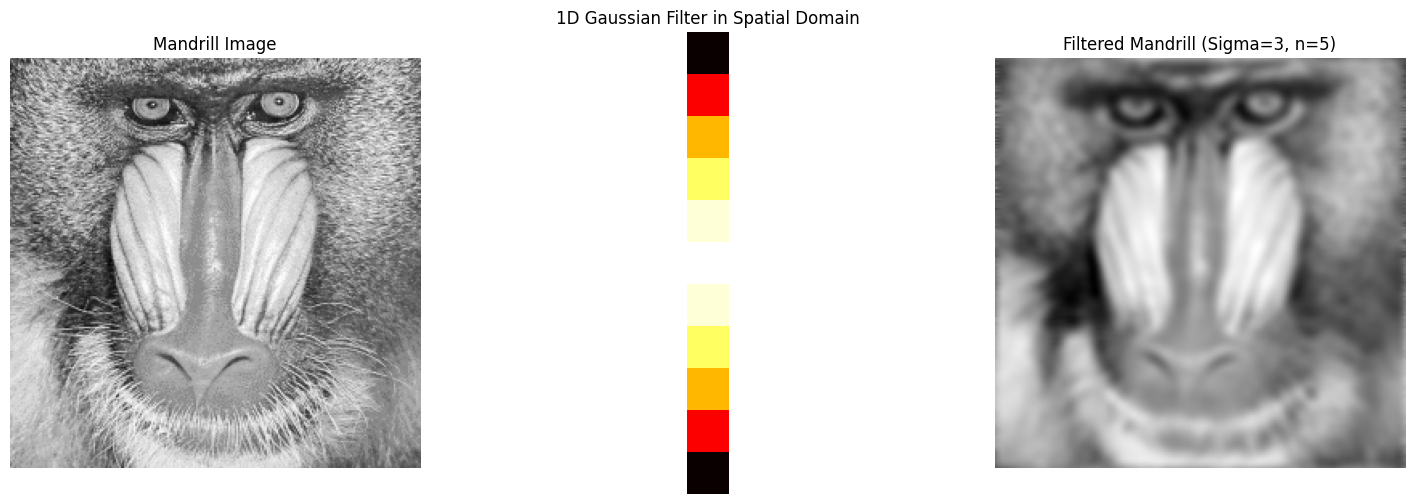

In [51]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(mandrill, cmap='gray')
plt.title('Mandrill Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(kernel_1d.reshape((2*n+1,1))), cmap='hot')  # Log scale for visibility
plt.title('1D Gaussian Filter in Spatial Domain')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_mandrill_spatial_1d, cmap='gray')
plt.title(f'Filtered Mandrill (Sigma={sigma}, n={n})')
plt.axis('off')

plt.show()

Il est intéressant d'utiliser un filtrage spatial 1d plutôt que 2d car cela permet de gagner en vitesse d'exécution. En effet, on réalise $2n*N^2$ opérations pour le 1d et $n^2*N^2$ pour le 2d, pour un résultat équivalent.

### Question 13: 
* ### Tracez l’erreur quadratique moyenne (MSE) entre le résultat du filtrage gaussien par FFT et le résultat d'un filtrage gaussien spatial en fonction de la taille du noyau de filtrage, par exemple, n allant de 1 à  6*sigma (pour des valeurs fixées de sigma = 1, 5, 10) pour les images formes2g.pgm et radio1024.pgm. Commentez les résultats.
* ### Déterminez approximativement la taille du filtre spatial $n = W(\sigma)$ (qui depend de $\sigma$) pour lequel les résultats sont similaires entre le filtrage fréquentiel par FFT et le filtrage spatial ?


tour  1
tour  2
tour  3
tour  4
tour  5
tour  6
tour  7
tour  8
tour  9
tour  10
tour  11
tour  12
tour  13
tour  14
tour  15
tour  16
tour  17
tour  18
tour  19
tour  20
tour  21
tour  22
tour  23
tour  24
tour  25
tour  26
tour  27
tour  28
tour  29
tour  30
tour  31
tour  32
tour  33
tour  34
tour  35
tour  36
tour  37
tour  38
tour  39
tour  40
tour  41
tour  42
tour  43
tour  44
tour  45
tour  46
tour  47
tour  48
tour  49


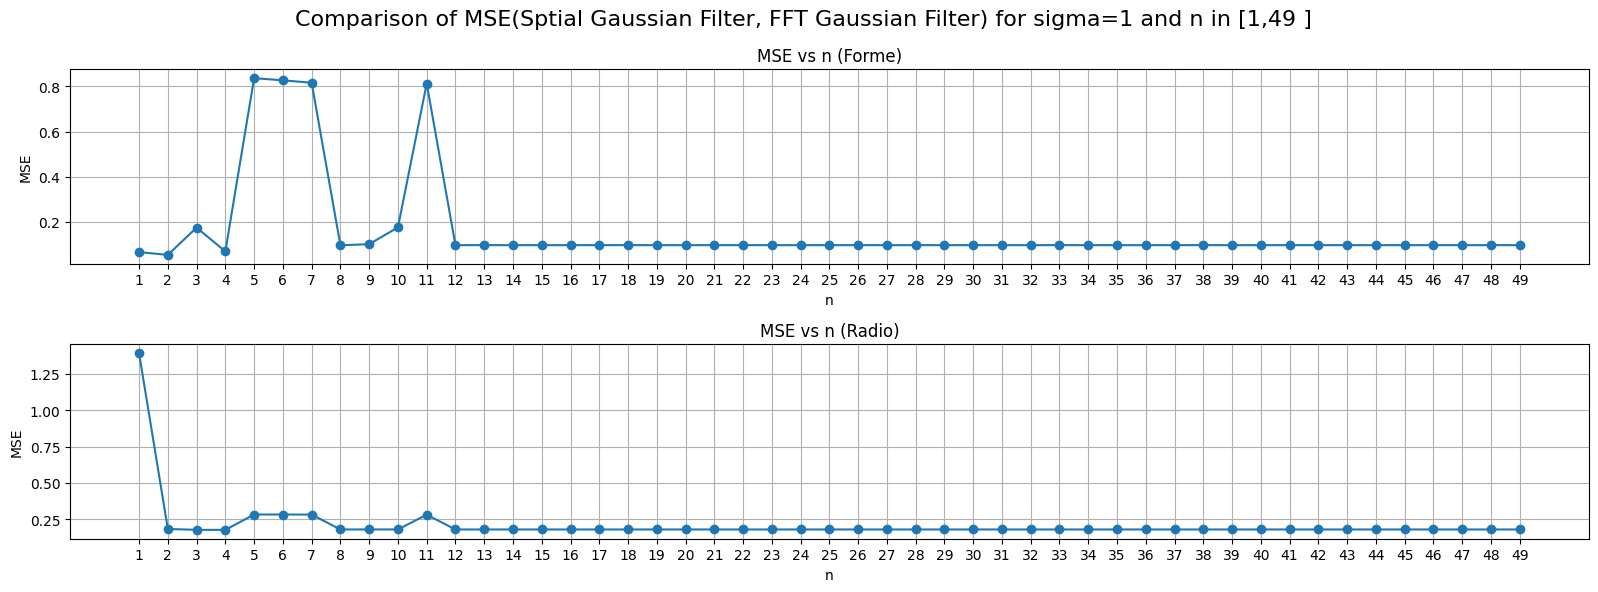

tour  1
tour  2
tour  3
tour  4
tour  5
tour  6
tour  7
tour  8
tour  9
tour  10
tour  11
tour  12
tour  13
tour  14
tour  15
tour  16
tour  17
tour  18
tour  19
tour  20
tour  21
tour  22
tour  23
tour  24
tour  25
tour  26
tour  27
tour  28
tour  29
tour  30
tour  31
tour  32
tour  33
tour  34
tour  35
tour  36
tour  37
tour  38
tour  39
tour  40
tour  41
tour  42
tour  43
tour  44
tour  45
tour  46
tour  47
tour  48
tour  49


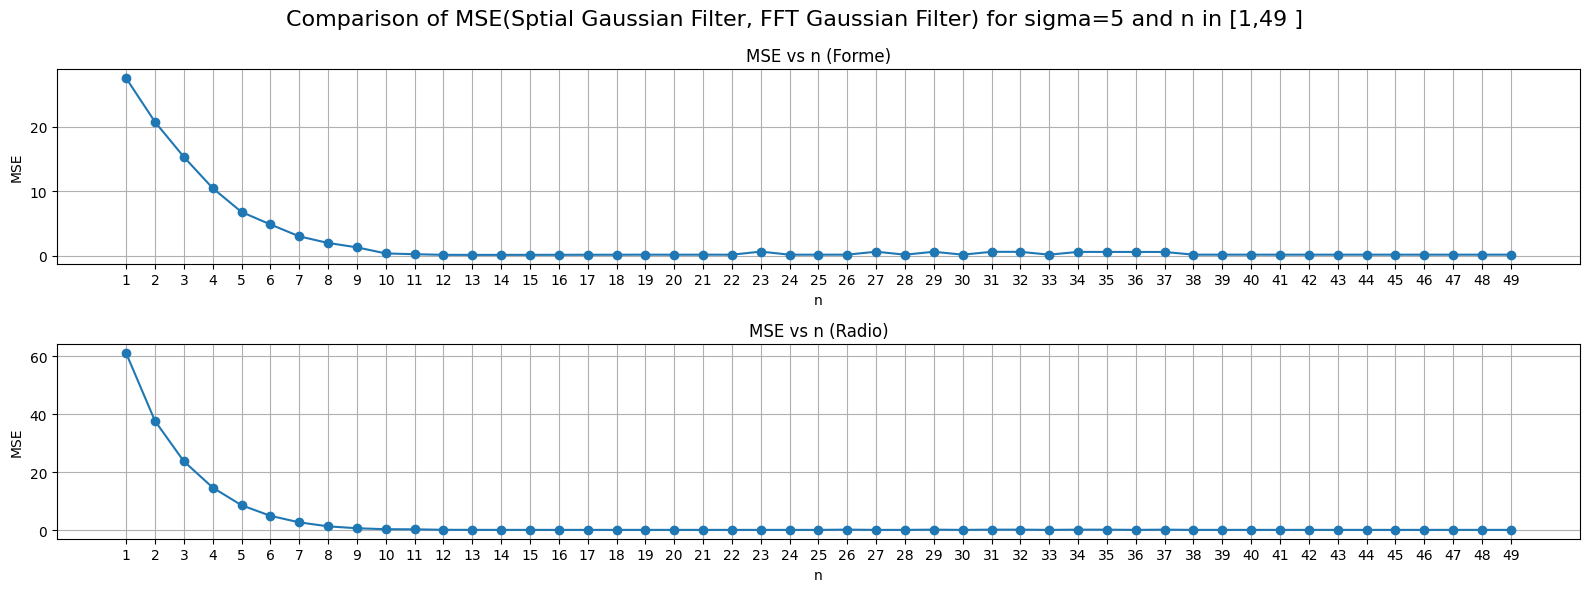

tour  1
tour  2
tour  3
tour  4
tour  5
tour  6
tour  7
tour  8
tour  9
tour  10
tour  11
tour  12
tour  13
tour  14
tour  15
tour  16
tour  17
tour  18
tour  19
tour  20
tour  21
tour  22
tour  23
tour  24
tour  25
tour  26
tour  27
tour  28
tour  29
tour  30
tour  31
tour  32
tour  33
tour  34
tour  35
tour  36
tour  37
tour  38
tour  39
tour  40
tour  41
tour  42
tour  43
tour  44
tour  45
tour  46
tour  47
tour  48
tour  49


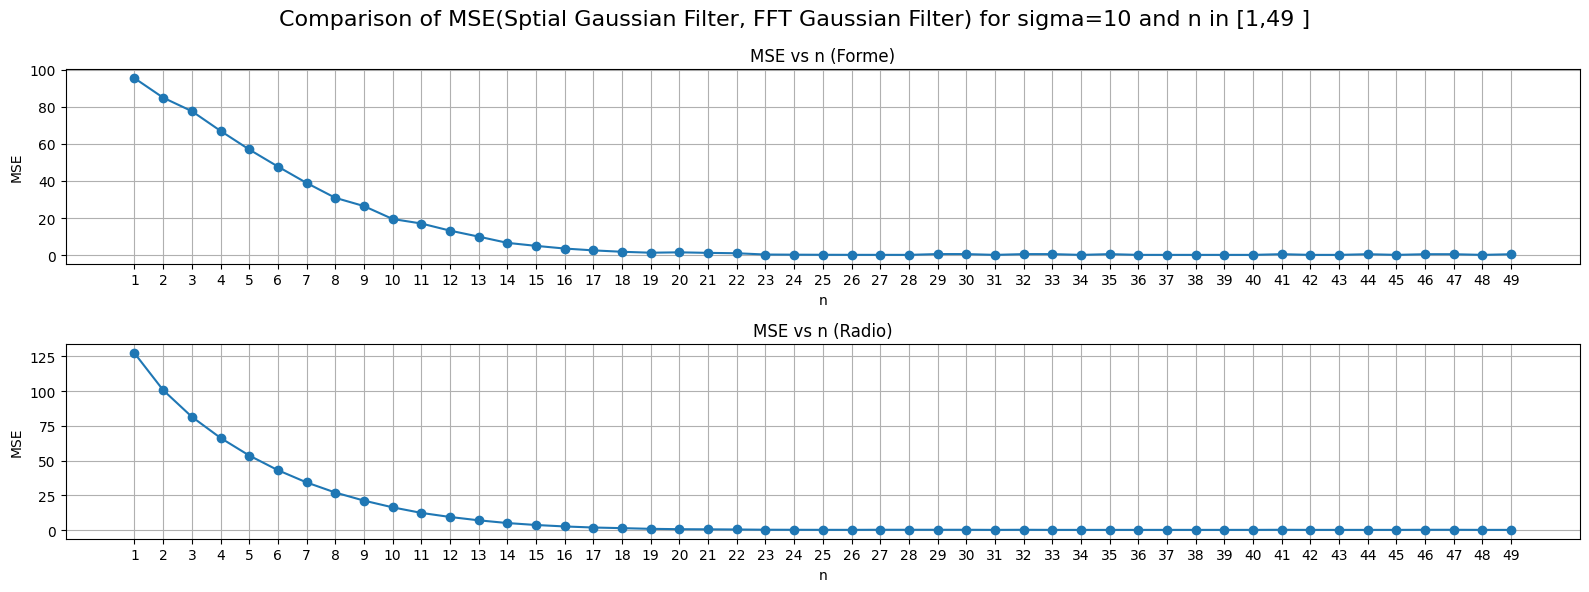

In [56]:
# Charger les images
image_1 = io.imread('Archive/formes2g.pgm')
image_2 = io.imread('radio1024.pgm')

# Définir les valeurs de sigma et les tailles de masque à tester
sigma_values = [1, 5, 10]
Ns = list(range(1,5*10))

for sigma in sigma_values:

    eqm_results_formes = []
    eqm_results_radio = []

    image_formes_fft, _ = frequency_gaussian_filter(image_1, sigma)
    image_radio_fft, _  = frequency_gaussian_filter(image_2, sigma)
    
    for n in Ns:

        print('tour ',n)
        kernel = gaussian_kernel_1d(n, sigma)
        image_formes_spatial = apply_1d_row_cols(image_1, kernel)
        image_radio_spatial  = apply_1d_row_cols(image_2, kernel)
        eqm_results_formes.append(np.mean((image_formes_fft-image_formes_spatial)**2))
        eqm_results_radio.append(np.mean((image_radio_fft-image_radio_spatial)**2))
        
    
    fig, ax = plt.subplots(2, 1, figsize=(16, 6)) 

    ax[0].plot(Ns, eqm_results_formes, marker='o')
    ax[0].set_xticks(Ns)
    ax[0].set_title('MSE vs n (Forme)')
    ax[0].set_xlabel('n')
    ax[0].set_ylabel('MSE')
    ax[0].grid(True)

    ax[1].plot(Ns, eqm_results_radio, marker='o')
    ax[1].set_xticks(Ns)
    ax[1].set_title('MSE vs n (Radio)')
    ax[1].set_xlabel('n')
    ax[1].set_ylabel('MSE')
    ax[1].grid(True)

    fig.suptitle(f'Comparison of MSE(Sptial Gaussian Filter, FFT Gaussian Filter) for sigma={sigma} and n in [{min(Ns)},{max(Ns)} ]', fontsize=16)

    plt.tight_layout()
    plt.show()



Cette question était compliqué à réaliser du fait du temps de calcul qu'elle impliquait. Initialement j'avais envisagé de mettre un pas important pour $\sigma$, mais au final cela m'empêchait de voir des phénomènes. Cependant je m'étais rendu compte que pour $\sigma > 50$ il ne se passait rien d'intéressant donc j'ai décidé de limiter $\sigma$ à $50$ et d'attendre. Cela m'a pris presque 30min pour exécuter cette cellule. 

On observe deux phénomènes intéressants :
-1er phénomène : Pour un $n$ fixé, la MSE est plus élevée plus $\sigma$ est élevé. C'est très cohérent, en effet, lorsque $\sigma$ est élevé, la zone $W(\sigma)$ est plus large, donc il faut un $n$ plus grand pour englober la totalité des valeurs du filtre.

-2eme phénomène : de manière générale, pour $\sigma$ fixé, lorsque $n$ augmente, l'erreur entre le filtrage spatial et FFT diminue. C'est cohérent. En effet, le filtrage par FFT est équivalent à appliquer un filtrage spatial avec $n=N$, $N$ étant la taille de l'image. lorsque $n$ augmente, on gagne en précision. On remarque qu'en général, lorsque $n \geq 3*\sigma$ la MSE est très proche de $0$. C'est cette valeur que j'ai choisie pour $W(\sigma)$ dans la question suivante. 

-artefacts de la courbe: Il se passe des choses étrange sur l'image Forme, surtout lorsque $\sigma$ est très faible. La MSE, initialement basse, augmente et fait des pics pour certaines valeurs de $n$. Ce phénomène est minime, en effet lorsque l'on regarde l'échelle de la courbe on se rend compte que la MSE ne dépasse pas 1. C'est seulement plus visible parce que comme $\sigma=1$, la valeur prépondérante dans la moyenne gaussienne est la valeur du pixel du milieu. Donc la MSE est en moyenne plus faible, et on voit donc mieux las apsérités de la courbe. Il se pourrait aussi qu'il y ait des effets à causes fréquences, mais je n'explique pas le phénomène. Dans tous les cas, la MSE restet inférieure à 1, ce qui est faible. 

### Question 14: 
* ### En utilisant une taille de masque n convenable (en fonction de sigma) dans le cas spatial, comparez les temps de calcul des 3 implémentations de filtrages gaussiens pour des paramètres sigma croissants pour les images formes2g.pgm, radio1024.pgm. 

* ### Pour quelles tailles de masque faut-il utiliser la version fréquentielle, la version spatiale 2D ou la version séparable 1D ?

In [58]:
import time
sigmas = list(range(1,21,4))

repetitions = 1
image_1 = io.imread('Archive/formes2g.pgm')
image_2 = io.imread('radio1024.pgm')

for sigma in sigmas:

    n = 3*sigma

    print('----------------------------Image Forme')
    image = image_1

    start_time = time.perf_counter()
    for r in range(repetitions):
        frequency_gaussian_filter(image, sigma)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre FFT : {execution_time:.5f} secondes")


    start_time = time.perf_counter()
    for r in range(repetitions):
        kernel = gaussian_kernel(n, sigma)
        apply_filter(image,kernel)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre spatial 2d : {execution_time:.5f} secondes")


    start_time = time.perf_counter()
    for r in range(repetitions):
        kernel = gaussian_kernel_1d(n, sigma)
        image_formes_spatial = apply_1d_row_cols(image_1, kernel)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre spatial 1d : {execution_time:.5f} secondes")


    print('----------------------------Image Radio')

    image = image_2

    start_time = time.perf_counter()
    for r in range(repetitions):
        frequency_gaussian_filter(image, sigma)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre FFT : {execution_time:.5f} secondes")


    start_time = time.perf_counter()
    for r in range(repetitions):
        kernel = gaussian_kernel(n, sigma)
        apply_filter(image,kernel)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre spatial 2d : {execution_time:.5f} secondes")


    start_time = time.perf_counter()
    for r in range(repetitions):
        kernel = gaussian_kernel_1d(n, sigma)
        image_formes_spatial = apply_1d_row_cols(image_1, kernel)
    end_time = time.perf_counter()
    execution_time = end_time - start_time
    print(f"Temps d'exécution filtre spatial 1d : {execution_time:.5f} secondes")

----------------------------Image Forme
Temps d'exécution filtre FFT : 0.00578 secondes
Temps d'exécution filtre spatial 2d : 0.35240 secondes
Temps d'exécution filtre spatial 1d : 0.57408 secondes
----------------------------Image Radio
Temps d'exécution filtre FFT : 0.08898 secondes
Temps d'exécution filtre spatial 2d : 5.12897 secondes
Temps d'exécution filtre spatial 1d : 0.56932 secondes
----------------------------Image Forme
Temps d'exécution filtre FFT : 0.00423 secondes
Temps d'exécution filtre spatial 2d : 0.47343 secondes
Temps d'exécution filtre spatial 1d : 0.59769 secondes
----------------------------Image Radio
Temps d'exécution filtre FFT : 0.08868 secondes
Temps d'exécution filtre spatial 2d : 7.46438 secondes
Temps d'exécution filtre spatial 1d : 0.56119 secondes
----------------------------Image Forme
Temps d'exécution filtre FFT : 0.00336 secondes
Temps d'exécution filtre spatial 2d : 0.67056 secondes
Temps d'exécution filtre spatial 1d : 0.57499 secondes
----------

Bilan : le filtre FFT est de loin le plus rapide dans tous les cas. Le filtre 1d est plus rapide que le 2d dans la plupart des cas, sauf sur l'image forme lorsque $\sigma$ (est donc $n$) est faible. Ce comportement est dû au facteur constant qui est plus élevé pour le filtre 1d puisqu'il y a deux boucles. Cela se voit lorsque $n$ est très faible et sur une image très petite. C'est un cas très margnial. Le comportement sur une image de taille normale (radio) confirme bien qu'asymptotiquement le filtrage 1d est bien plus rapide que le filtre 2d.

Dans tous les cas il est plus intéressant de passer par la FFT pour réaliser un filtrage gaussien car c'est de loin la méthode la plus rapide. En effet, la FFT est en $O(N\log(N))$, et la multiplication qui s'ensuit est en $O(N^2)$, ce qui est bien plus rapide que le filtrage 1d ou 2d de l'ordre de $O((n+m).N^2)$ pour le filtre 1d et $O(n^2.N^2)$ ce qui est bien plus important lorsque n devient grand.

### Question 15: 
* ### Définissez brièvement les filtres médian et de variation totale (TV), ainsi que leurs différences avec le filtre gaussien. Vous pourrez consulter les liens [lien1](https://en.wikipedia.org/wiki/Total_variation_denoising), [lien2](https://fr.wikipedia.org/wiki/Filtre_m%C3%A9dian). 

* ### Appliquez les trois filtres suivants : ndimage.gaussian_filter, filter.median_filter(coins) et l'un de vos filtres, à une image de votre choix, puis affichez les résultats. Interprétez les résultats.

* ### Tracez un signal sinusoïdal, ajoutez du bruit gaussien d'écart-type 0.5, puis utilisez un filtre de votre choix pour éliminer le bruit. Affichez votre signal avant et après l'application du filtre. Interprétez les résultats.

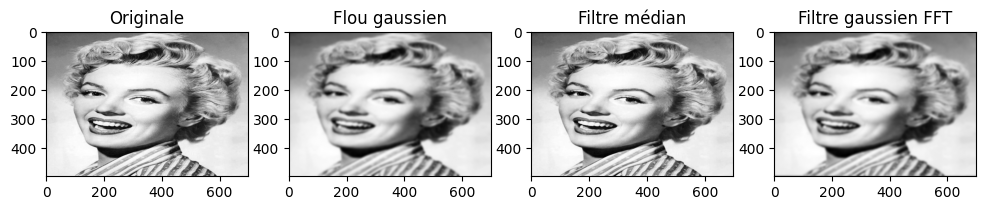

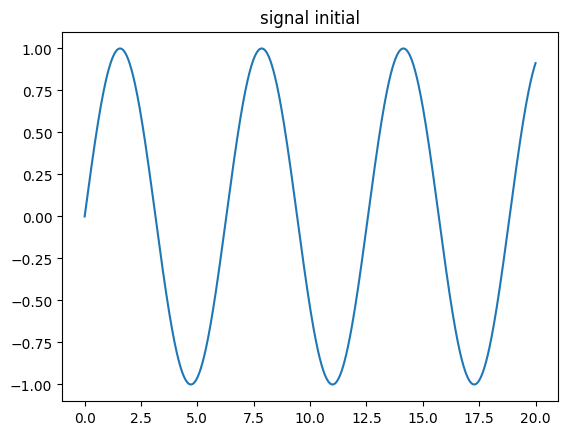

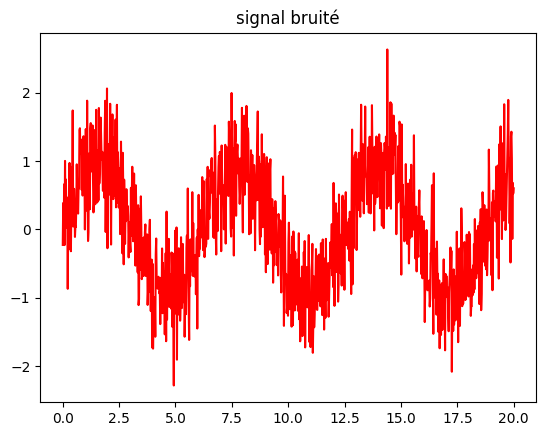

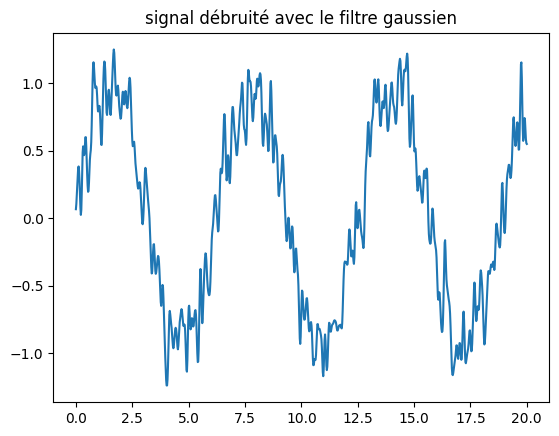

In [93]:
from skimage import filters
from scipy import ndimage


image = io.imread('monroe.pgm')

gaussian = ndimage.gaussian_filter(image, sigma=3)
median = filters.median(image)
# Exemple de filtre personnalisé : filtre moyen
FFT_filtered, _ = frequency_gaussian_filter(image, sigma = 3)

# Afficher les résultats
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Originale')
axes[1].imshow(gaussian, cmap='gray')
axes[1].set_title('Flou gaussien')
axes[2].imshow(median, cmap='gray')
axes[2].set_title('Filtre médian')
axes[3].imshow(FFT_filtered, cmap='gray')
axes[3].set_title('Filtre gaussien FFT')
plt.show()

X = np.linspace(0,20,1000)
signal = np.sin(X)
signal_bruite = signal + np.random.normal(loc=0.0, scale=0.5, size = X.shape)
signal_debruite = ndimage.gaussian_filter(signal_bruite, sigma=2)
plt.plot(X,signal)
plt.title("signal initial")
plt.show()
plt.plot(X,signal_bruite, c='r')
plt.title("signal bruité")
plt.show()
plt.plot(X,signal_debruite)
plt.title("signal débruité avec le filtre gaussien")
plt.show()

Le filtre median est un filtre qui consiste à prendre la médiane des pixels voisins pour le calcul du nouveau pixel. Cela permet de réduire le bruit de manière très efficace sans altérer les contours. Contrairement au filtre gaussien, il ne floute pas l'image. Il est peu sensible aux hautes valeurs. Il est donc très efficace pour éliminer le bruit de type poivre et sel. Parfois le tri des valeurs peut être plus lent que le calcul matriciel des filtres.

Le filtre de variance totale est un filtre dont le but est de réduire le bruit en préservant les contours. Il procède en minimisant une fonction d'erreur qui prend en compte l'intégrale du Gradient, et l'erreur entre l'image et l'image orignale. Cela permet de réduire le bruit sans perdre en qualité de contour. 

Pour les images, on observe que les images avec filtres gaussien (le notre et celui de Ndimage) sont un peu plus floues que l'image initiale, ce qui est cohérent avec ce que l'on a observé depuis le début du TP. L'image filtrée avec le filtre médian n'est pas du tout floue, elle a conservé les contours. L'image initiale ne contenait pas beaucoup de bruit donc il est difficile d'apercevoir des effets de ce filtre. En zoomant, on peut distinguer que les zones de couleur unies paraissent plus lisses, mais c'es très minime.

Pour les signaux, j'ai représenté le sinus initial, puis le signal bruité, puis débruité avec le bruit gaussien. On remarque au visuel que le bruit semble avoir été réduit par le débruitage. On aperçoit beaucoup mieux le signal initial. 

# Références

* tp1.pdf partie 1 lissage linéaire depuis https://chamilo.grenoble-inp.fr/

* Cours2-TI-filtrage-2019.pdf depuis https://chamilo.grenoble-inp.fr/

* Filtrage d'images: https://fr.slideshare.net/mostafadess/filtrage-image-232669739

* Tutorial: https://zestedesavoir.com/tutoriels/1557/introduction-au-traitement-dimage/